# Post-Fire Ecosystem Recovery Prioritization Using Multi-Temporal Sentinel-2 Satellite Imagery
This project aims to identify burned areas and monitor their post-fire vegetation recovery using multi-temporal Sentinel-2 satellite imagery. The analysis combines differenced Normalized Burn Ratio (dNBR) and Normalized Difference Vegetation Index (NDVI) recovery rate because they capture two complementary aspects of wildfire impact: dNBR quantifies the initial severity of vegetation disturbance caused by fire, while NDVI recovery measures the ecosystem response and regeneration after the event.

Reference: https://www.mdpi.com/2072-4292/14/19/4714

## Methodology

The workflow follows a two-stage approach:

1. **Burn severity assessment**
The burned areas are identified using the Normalized Burn Ratio (NBR) and its temporal difference (dNBR):

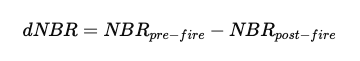

where NBR is calculated from Sentinel-2 near-infrared and short-wave infrared bands. Higher dNBR values indicate greater vegetation disturbance caused by the fire.

2. **Post-fire vegetation recovery monitoring**

Vegetation recovery is quantified using the normalized NDVI recovery rate:

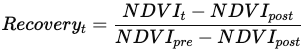

where:
- NDVIpre represents vegetation condition before the fire,
- NDVIpost represents the immediate post-fire vegetation condition,
- NDVIt represents vegetation condition during the monitoring period.

This metric measures the relative progress of vegetation regeneration compared with the pre-fire baseline. A recovery value close to 1 indicates vegetation conditions approaching the pre-fire state, while values close to 0 indicate limited recovery.


## Decision Intelligence

The objective is not only to map burned areas, but also to provide a decision-support product for post-fire restoration planning.

The analysis aggregates pixel-level indicators into burned-area polygons and assigns each polygon a recovery priority based on ecological conditions:

**Burn severity** (dNBR): represents the magnitude of the initial disturbance.
**Vegetation recovery rate** (NDVI recovery): represents the ecosystem response after the fire.

Areas with high burn severity and limited vegetation recovery are considered higher priority for further inspection, while areas showing strong natural regeneration are classified as lower priority.

The final output includes:

- Burn severity map (dNBR raster)
- Vegetation recovery (NDVI recover raster) map over monitoring periods
- Polygon-level recovery statistics
- Decision-ready GeoJSON containing:
    - burned area extent,
    - burn severity class,
    - vegetation recovery rate,
    - recommended decision:
        - Immediate inspection
        - Monitor
        - No intervention


## The expected input: 
1. Location (lat, lon)
2. Dates:
    - Pre_date: acquisition date before the fire occurance, used as baseline T0
    - Post_date: acquisition date after the fire occurance, used as baseline T1
    - Monitoring schedule: a list of acquisition dates used to track vegetation recovery over time.
3. Temporal buffer (days) : Number of days around each requested date used to search for valid Sentinel-2 acquisitions.
4. radius (m): Radius around the input coordinate defining the analysis extent.

Example cases: Gironde wildfire, France; lon lat -1.18168, 44.57616; pre date 01 to 10 July 2022; post date 01 to 10 August 2023



In [1]:
import os
from datetime import datetime, timedelta
from glob import glob

import geopandas
import geopandas as gpd
import leafmap
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer as pc
import pystac_client
import rasterio as rio
import rioxarray as rioxr
import utm
import xarray as xr
from odc.stac import stac_load
from PIL import Image
from pyproj import CRS, Transformer
from pyproj.aoi import AreaOfInterest
from pyproj.database import query_utm_crs_info
from rasterio.features import shapes
from shapely.geometry import shape
from tqdm import tqdm

In [2]:
def get_bbox(lon, lat, half_size_m):
    easting, northing, zone_number, zone_letter = utm.from_latlon(lat,lon)
    xmin = easting - half_size_m
    xmax = easting + half_size_m
    ymin = northing - half_size_m
    ymax = northing + half_size_m
    min_lat, min_lon = utm.to_latlon(xmin, ymin, zone_number, zone_letter) 
    max_lat, max_lon = utm.to_latlon(xmax, ymax, zone_number, zone_letter)
    return [min_lon.item(), min_lat.item(), max_lon.item(), max_lat.item()]
    
def bbox_to_epsg(min_lon, min_lat, max_lon, max_lat):
    crs_list = query_utm_crs_info(
        datum_name="WGS 84",
        area_of_interest=AreaOfInterest(
            west_lon_degree=min_lon,
            south_lat_degree=min_lat,
            east_lon_degree=max_lon,
            north_lat_degree=max_lat,
        ),
    )
    return crs_list[0].code if crs_list else None

def buffer_date(date: str, buffer:int, mode='center'):
    date = datetime.strptime(date, "%d-%m-%Y")
    if mode == "left":
        start = date - timedelta(days=buffer)
        end = date
    elif mode == "right":
        start = date
        end = date + timedelta(days=buffer)
    elif mode == "center":
        left = buffer // 2
        right = buffer - left 
        start = date - timedelta(days=left)
        end = date + timedelta(days=right)
    else:
        raise ValueError("mode must be 'left', 'right', or 'center'")
    return (
        f"{start.strftime('%Y-%m-%d')}/"
        f"{end.strftime('%Y-%m-%d')}"
        )

def get_s2(bbox, datetime, save_dir, filename, 
           max_cloud_cover=20, max_item=10, resolution=10, bands=None):
    if not bands:
        bands = [
                "B12", "B11", "B09", "B8A", 
                "B08", "B07", "B06", "B05", 
                "B04", "B03", "B02", "B01"
                ]
    proj_epsg =  bbox_to_epsg(*bbox)

    kwargs_search_s2 = dict(
            bbox=bbox,
            datetime=datetime,
            query={"eo:cloud_cover": {"lte": max_cloud_cover}},
            max_items=max_item
            )       
    kwargs_load_s2 = dict(
        bbox=bbox,
        bands=bands,
        chunks={"x": 256, "y": 256, "time": 1},
        resolution=resolution,
        dtype="uint16",
        crs=f"epsg:{proj_epsg}",
        nodata=0)
    
    catalog="https://planetarycomputer.microsoft.com/api/stac/v1"
    catalog_pystac = pystac_client.Client.open(catalog)
    search = catalog_pystac.search(collections=["sentinel-2-l2a"], **kwargs_search_s2)
    items = search.item_collection()
    print(f'number of S2 scenes found for {filename}: {len(items)}')
    if len(items)==0:
        return 0
    os.makedirs(save_dir, exist_ok=True)
    df = geopandas.GeoDataFrame.from_features(items.to_dict(), crs=f"epsg:{proj_epsg}")
    df.to_csv(f'{save_dir}/{filename}.csv')
    signed_items = [pc.sign(item) for item in items]
    ds_saved = stac_load(signed_items, groupby='id', **kwargs_load_s2)
    ds_saved = ds_saved.rio.write_crs(f"epsg:{proj_epsg}", inplace=True)
    ds_saved.to_zarr(f'{save_dir}/{filename}.zarr', mode="w", consolidated=True, zarr_format=2)
    return f'{save_dir}/{filename}.zarr'

def preprocessing(ds, mask_class=[0, 1, 3, 8, 9, 10, 11]):
    mask = ds['SCL'].isin(mask_class)
    ds_cloudless = ds.where(~mask)
    ds_cloudless = ds_cloudless.drop_vars("SCL")
    ds_median = ds_cloudless.median(dim='time', skipna=True)
    ds_scaled = ds_median/10_000
    return ds_scaled

def cal_ndvi_s2(ds):
    denom = ds['B08'] + ds['B04']
    ds['NDVI'] = xr.where(denom!=0, (ds['B08'] - ds['B04'])/denom, float("nan"))
    return ds

def cal_nbr_s2(ds):
    denom = ds['B08'] + ds['B12']
    ds['NBR'] = xr.where(denom!=0, (ds['B08'] - ds['B12'])/denom, float("nan"))
    return ds

def cal_dnbr(ds_pre, ds_post):
    da = (ds_pre['NBR']- ds_post['NBR']).rename("dNBR")
    return da

def cal_rndvi(ds_pre, ds_post, ds_t):
    denom = ds_pre["NDVI"] - ds_post["NDVI"]
    da = xr.where(denom > 0,(ds_t["NDVI"]-ds_post["NDVI"])/denom, 1).rename("rNDVI")
    da = xr.where(da>1, 1, da)
    return da

def cal_mean_zone(da_xarray, da_numpy, geom):
    mask = rio.features.geometry_mask(
           [geom],
           out_shape=da_xarray.shape,
           transform=da_xarray.rio.transform(),
           invert=True)
    values = da_numpy[mask]
    mean_val = np.nanmean(values)
    return mean_val

def classify_priority(priority_score, top, bottom):
    if priority_score > top:
        return "High"
    elif priority_score >= bottom:
        return "Medium"
    else:
        return "Low"

def action(priority_score, top, bottom):
    if priority_score > top:
        return "Immediate inspection"
    elif priority_score >= bottom:
        return "Monitor"
    else:
        return "No intervention"

# Project config

In [3]:
DATA_DIR = './data'
TEMP_DIR = DATA_DIR + '/temp'
DELIVERY_DIR = DATA_DIR + '/deliverables'
os.makedirs(TEMP_DIR, exist_ok=True)
os.makedirs(DELIVERY_DIR, exist_ok=True)

# project input
lat, lon = 44.57616, -1.18168
pre_date = '10-07-2022'
post_date = '01-08-2022'
schedules = ['15-04-2023', '15-07-2023', '15-10-2023', '15-03-2024']
temporal_buffer = 10
radius = 10_000

# Data acquisition

The pre-downlaod S2 dataset is provided on this link. It is to prevent some disturbs during downloading either from server or network side. In that case, please comment the lines to download the S2 data.

In [ ]:
# Prepare arguments for data acquisition
bbox = get_bbox(lon, lat, radius)
pre_daterange = buffer_date(pre_date, temporal_buffer, 'left')
post_daterange = buffer_date(post_date, temporal_buffer, 'right')
schedule_dateranges = [buffer_date(date, 30, 'center') for date in schedules]
bands = ["B04", "B03", "B02", "B08", "B12", "SCL"]

# Satellite config
max_cloud_cover=20
resolution=10
max_item=10

# Acquire the satellite imageries
get_s2(bbox, pre_daterange, TEMP_DIR, 'pre_event', bands=bands, max_cloud_cover=max_cloud_cover, max_item=max_item, resolution=resolution)
get_s2(bbox, post_daterange, TEMP_DIR, 'post_event', bands=bands, max_cloud_cover=max_cloud_cover, max_item=max_item, resolution=resolution)
[get_s2(bbox, s_date, TEMP_DIR, f'monitored_sched_t{i+1}', bands=bands, max_cloud_cover=max_cloud_cover, max_item=max_item, resolution=resolution)for i, s_date in enumerate(schedule_dateranges)]

# Preprocessing 

Preprocessing comprises:
- Cloud masking using SCL to filter out bad data
- Temporal median composite to fill gaps and reduce noice
- Reflectance scale to ensure compatibility with the spectral index calculation

In [4]:
s2_paths = ['./data/temp/pre_event.zarr',
         './data/temp/post_event.zarr',
         './data/temp/monitored_sched_t1.zarr',
         './data/temp/monitored_sched_t2.zarr',
         './data/temp/monitored_sched_t3.zarr',
         './data/temp/monitored_sched_t4.zarr',
         ]

mask_class=[0, 1, 3, 8, 9, 10, 11]
ds = xr.open_zarr(s2_paths[0])
crs = CRS.from_wkt(ds['spatial_ref'].attrs['spatial_ref']).to_epsg()
print('crs', crs)
ds_list = [preprocessing(xr.open_zarr(path), mask_class) for path in s2_paths]
ds_list = [ds.rio.write_crs(f"epsg:{crs}", inplace=True) for ds in ds_list] # apply crs
print('check crs', ds_list[0].rio.crs)

crs 32630
check crs EPSG:32630


# Indicies calculation

The indicies calculation uses the following formulas:

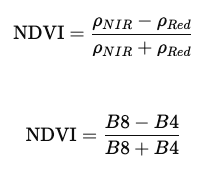

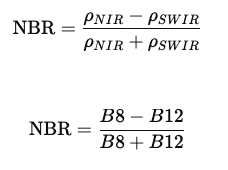

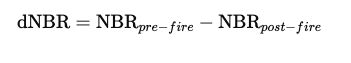

In [5]:
# NDVI
ds_list = [cal_ndvi_s2(ds) for ds in ds_list]

In [6]:
# NBR
ds_list = [cal_nbr_s2(ds) for ds in ds_list]
ndbr_ds_list = [cal_dnbr(ds_list[0], ds) for ds in ds_list[1:]]

# Analysis

## Severity

Severity Classification is following the [Key & Banson, 2006](https://research.fs.usda.gov/treesearch/24066) with some modification on number of classes. There 3 classes of burned area: Low with dNBR between 0.1 and 0.269, medium with dNBR between 0.27 and 0.659 and high with dNBR >= 0.66

 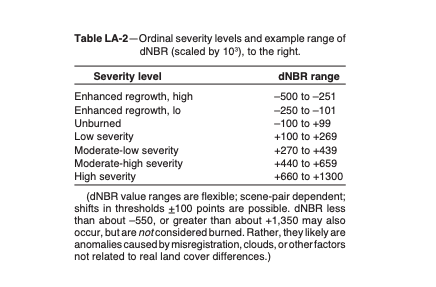

In [7]:
# Get burned areas/region
severity_cls = {
    1:'low',
    2:'moderate',
    3:'High' 
}
ndbr_base = ndbr_ds_list[0]
severity_class = xr.zeros_like(ndbr_base, dtype="uint8")
severity_class = xr.where((ndbr_base >= 0.10) & (ndbr_base < 0.27), 1, severity_class)
severity_class = xr.where((ndbr_base >= 0.27) & (ndbr_base < 0.66), 2, severity_class)
severity_class = xr.where(ndbr_base >= 0.66, 3, severity_class)

In [8]:
# get the Severity geometry
# severity_class = severity_class.rio.write_crs(f"epsg:{crs}", inplace=True)
geoms = [
    {'geometry': shape(geom),
     'severity': severity_cls[value]
     } for geom, value in shapes(severity_class.data, mask=severity_class.astype(bool), transform=severity_class.rio.transform())
     ]

gdf = gpd.GeoDataFrame(geoms, crs=crs)
gdf['area_ha'] = gdf.geometry.area/10_000 # in ha
gdf.to_file(f"{TEMP_DIR}/baseline_burned_area.geojson", driver="GeoJSON")

In [9]:
# Get the mean dNBR for each geometry
# ndbr_base 
ndbr_base_values = ndbr_base.values
gdf[f"mean_dNBR_base"] = [cal_mean_zone(ndbr_base, ndbr_base_values, geom) for geom in tqdm(gdf.geometry)]

100%|██████████| 17313/17313 [00:32<00:00, 528.84it/s]


## Recovery rate (rNDVI)

NDVI recovery rate quantifies the degree of vegetation regrowth after a wildfire by comparing post-fire NDVI conditions with the pre-fire vegetation state. The metric is normalized between the immediate post-fire condition and the pre-fire baseline, where a value close to 1 indicates that vegetation has recovered to pre-fire conditions, while a value close to 0 indicates limited recovery.

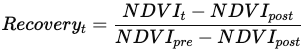

In [10]:
ndvi_recovers = [cal_rndvi(ds_list[0], ds_list[1], ds_t) for ds_t in ds_list[2:]]
for i, da in enumerate(ndvi_recovers):
    print(f'calculate ndvi for monitor schedule {i+1}')
    da_values = da.values
    gdf[f"mean_recovery_t{i+1}"] = [
        cal_mean_zone(da, da_values, geom)
        for geom in tqdm(gdf.geometry)
    ]

calculate ndvi for monitor schedule 1


100%|██████████| 17313/17313 [00:38<00:00, 446.90it/s]


calculate ndvi for monitor schedule 2


100%|██████████| 17313/17313 [00:33<00:00, 509.42it/s]


calculate ndvi for monitor schedule 3


100%|██████████| 17313/17313 [00:30<00:00, 562.71it/s]


calculate ndvi for monitor schedule 4


100%|██████████| 17313/17313 [00:34<00:00, 505.56it/s]


## Prioritization

**Decision question**: Which burned areas should be prioritized for ecological restoration based on fire severity and vegetation recovery trajectory?

**Intended users**:
- Forest management agency
- National park authority
- Environmental restoration team

**Decision Rule**: Post-fire Recovery Prioritization

The objective of this analysis is to identify burned areas that require attention after a wildfire by assessing their ecological condition and recovery status. The decision is designed to support restoration planning by identifying areas where natural vegetation recovery appears insufficient and where further field assessment may be needed.

Each burned polygon is assigned an ecological priority score based on two complementary indicators:

1. **Burn severity**, represented by the mean dNBR within the burned polygon. Higher dNBR values indicate greater vegetation disturbance and potential ecological damage.

2. **Post-fire vegetation recovery**, represented by the NDVI recovery ratio relative to pre-fire conditions. Lower recovery values indicate that vegetation has not yet returned to its pre-fire condition and may require additional investigation or intervention. In this task, the latest NDVI recovery ratio is used. 

The ecological priority score is calculated as:


Priority = 0.6S + 0.4(1-R)

where:

* (S) is the mean dNBR within the polygon,
* (R) is the normalized NDVI recovery (rNDVI) ratio at selected monitoring time.

The weighting gives slightly higher importance to burn severity because the magnitude of the initial disturbance is a key determinant of potential ecological impact, while recovery status provides information on whether the ecosystem is naturally regenerating after the disturbance.

Based on the resulting priority score, burned polygons are assigned to three management action categories:

|Priority value|  Priority class | Decision              | Interpretation                                                                                                                                     |
|--------------|  ---------------| --------------------  | -------------------------------------------------------------------------------------------------------------------------------------------------- |
|> 0.7         |  High           | Immediate inspection  | Areas with high burn severity and limited vegetation recovery. These locations should be prioritised for field assessment or restoration planning. |
|0.4 - 0.7     |  Medium         | Monitor               | Areas showing partial recovery or moderate disturbance. These locations should continue to be monitored to evaluate natural regeneration.          |
|< 0.4         |  Low            | No intervention       | Areas with low disturbance or strong vegetation recovery, where natural recovery appears sufficient.                                               |

The thresholds are defined as an initial decision framework and can be refined using local ecological knowledge, restoration objectives, or historical recovery observations.


In [11]:
gdf['priority_score_at_t4'] = 0.6 * gdf['mean_dNBR_base'] + 0.4 * (1-gdf['mean_recovery_t4'])
gdf['priority_cls_at_t4'] = gdf['priority_score_at_t4'].apply(lambda r: classify_priority(r, 0.7, 0.4))
gdf['action_at_t4'] = gdf['priority_score_at_t4'].apply(lambda r: action(r, 0.7, 0.4))

In [12]:
final_gdf = gdf[['severity', 'mean_recovery_t4', 'priority_cls_at_t4', 'action_at_t4', 'area_ha', 'geometry']]
final_gdf

,severity,mean_recovery_t4,priority_cls_at_t4,action_at_t4,area_ha,geometry
0,moderate,1.000000,Low,No intervention,0.01,"POLYGON ((638010 4947480, 638010 4947470, 6380..."
1,low,-1.039605,High,Immediate inspection,0.02,"POLYGON ((645030 4947470, 645030 4947460, 6450..."
2,low,-12.917953,High,Immediate inspection,0.01,"POLYGON ((647270 4947460, 647270 4947450, 6472..."
3,low,1.000000,Low,No intervention,0.06,"POLYGON ((638040 4947480, 638040 4947440, 6380..."
4,moderate,1.000000,Low,No intervention,0.02,"POLYGON ((638050 4947460, 638050 4947440, 6380..."
...,...,...,...,...,...,...
17308,low,-0.742301,High,Immediate inspection,0.01,"POLYGON ((636920 4927480, 636920 4927470, 6369..."
17309,low,-4.294972,High,Immediate inspection,0.01,"POLYGON ((652910 4927480, 652910 4927470, 6529..."
17310,low,0.032439,Medium,Monitor,0.05,"POLYGON ((654220 4927490, 654220 4927480, 6542..."
17311,low,-0.589131,Medium,Monitor,0.02,"POLYGON ((654290 4927480, 654290 4927470, 6543..."


# Deliverables

Requirements:
1. At least a RGB.png from an observation
2. At least a plot of time series
3. At least a georeference raster at COG
4. At least a GeoJSON
5. All vector and raster must be able to visualise on.

In [13]:
#  COG and RGB.png files
s2_paths = ['./data/temp/pre_event.zarr',
         './data/temp/post_event.zarr',
         './data/temp/monitored_sched_t1.zarr',
         './data/temp/monitored_sched_t2.zarr',
         './data/temp/monitored_sched_t3.zarr',
         './data/temp/monitored_sched_t4.zarr',
         ]

for i, path in enumerate(s2_paths):
    filename = os.path.basename(path).split('.')[0]
    ds = xr.open_zarr(path).isel(time=0)
    ds = ds.rio.write_crs(f"epsg:{crs}", inplace=True)
    ds.rio.to_raster(f'{DELIVERY_DIR}/{filename}_s2.tif',  
                    driver="COG", 
                    compress="ZSTD",
                    blocksize=512,
                    overview_resampling="nearest")

    da = ds[["B04", "B03", "B02"]].to_array('band')
    rgb = da.transpose("y", "x", "band").values.astype(np.float32)
    p2, p98 = np.nanpercentile(rgb, (2, 98))
    img = np.clip((rgb - p2) / (p98 - p2), 0, 1)
    Image.fromarray((img * 255).astype(np.uint8)).save(f"{DELIVERY_DIR}/{filename}_rgb.png")

In [14]:
# COG of dNBR and rNVI
ndbr_base = ndbr_base.rio.write_crs(f"epsg:{crs}", inplace=True)
ndbr_base.rio.to_raster(f'{DELIVERY_DIR}/dNBR_base.tif',  
                    driver="COG", 
                    compress="ZSTD",
                    blocksize=512,
                    overview_resampling="nearest")

for i, ds in enumerate(ndvi_recovers):
    ds = ds.rio.write_crs(f"epsg:{crs}", inplace=True)
    ds.rio.to_raster(f'{DELIVERY_DIR}/rndvi_t{i+1}.tif',  
                    driver="COG", 
                    compress="ZSTD",
                    blocksize=512,
                    overview_resampling="nearest")
    

In [15]:
# COG of NDVI, NBR, 
for i, ds in enumerate(ds_list):
    filename = os.path.basename(s2_paths[i]).split('.')[0]
    ds = ds.rio.write_crs(f"epsg:{crs}", inplace=True)
    for index in ["NDVI", "NBR"]:
        da = ds[index]
        da.rio.to_raster(f'{DELIVERY_DIR}/{filename}_{index}.tif',  
                        driver="COG", 
                        compress="ZSTD",
                        blocksize=512,
                        overview_resampling="nearest")


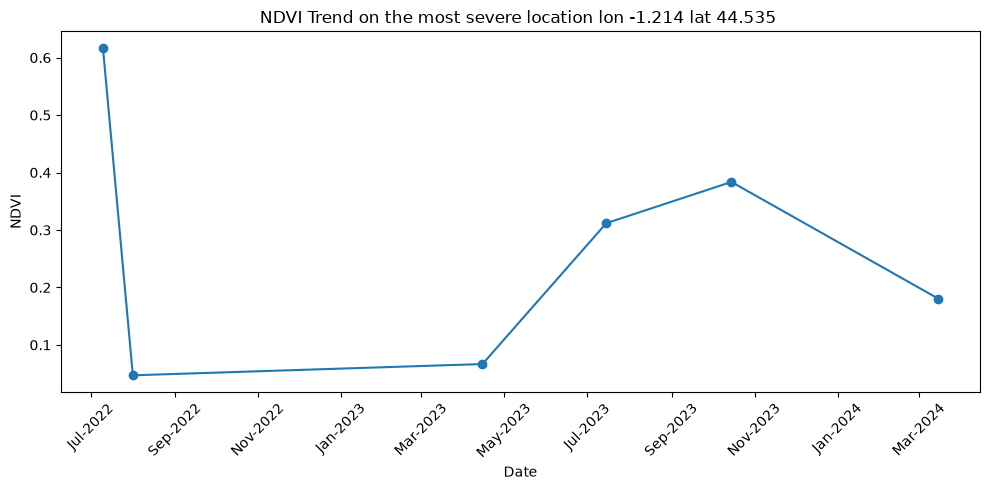

In [16]:
# Time series plot at the most severe burned location
max_loc = ndbr_base.stack(pixel=("x", "y")).idxmax("pixel")
x, y = max_loc.values
ndvi_da = [ds["NDVI"] for ds in ds_list]
ndvi_ts = xr.concat(ndvi_da, dim='time')
ndvi_ts = ndvi_ts.assign_coords(time=pd.to_datetime(['10-07-2022', '01-08-2022', '15-04-2023', '15-07-2023', '15-10-2023', '15-03-2024'], format="%d-%m-%Y" ))
pixel_ts = ndvi_ts.sel(x=x, y=y, method="nearest")
transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
lon, lat =transformer.transform(x, y)

fig, ax = plt.subplots(figsize=(10, 5))
pixel_ts.plot(ax=ax, marker="o")
ax.set_xlabel("Date")
ax.set_ylabel("NDVI")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
ax.set_title(f"NDVI Trend on the most severe location lon {round(lon,3)} lat {round(lat, 3)} ")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{DELIVERY_DIR}/ndvi_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
# Decision-ready artefact in geojson
final_gdf.to_file(f"{DELIVERY_DIR}/actionable_evaluation.geojson", driver="GeoJSON")

# Visualization

It shows: 
- The RGB of pre_event, post_event, and monitoring schedules
- The actionable evaluation.geojson

In [18]:
colormap={
        1: (255, 255, 0), #"yellow", low severity
        2: (255, 165, 0), #"orange", moderate severity
        3: (255, 0, 0), #"red", high severity
    }
severity_class = severity_class.rio.write_crs(f'epsg:{crs}', inplace=True)
severity_lm = leafmap.array_to_image(severity_class, colormap=colormap)
 
m = leafmap.Map(center=[lon, lat], zoom=15, width="100%",height="800px")
m.add_raster(severity_lm, layer_name='Severity raster', nodata=0)
m.add_gdf(final_gdf, layer_name="Severity vector", style_function=lambda feature: {
        "fillColor": "transparent",
        "color": "blue",
        "weight": 2,
        "fillOpacity": 0,
    }
)

# RGB of preprocessed images
for i, ds in enumerate(ds_list):
    filename = os.path.basename(s2_paths[i]).split('.')[0]
    ds = ds[["B04", "B03", "B02"]].to_array("band").assign_coords(band=["B04", "B03", "B02"])
    m.add_raster(ds, indexes=[1, 2, 3], vmin=0.1, vmax=0.5, layer_name=f"S2 RGB {filename}")
    
m

Map(center=[44.576066499999996, -1.1810935], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_…

# Wrap-up

This project demonstrates an end-to-end Earth Observation workflow for post-fire recovery assessment, combining burn severity mapping using dNBR and vegetation recovery monitoring using NDVI recovery rate to transform satellite observations into a decision-support product. The core methodological choice was to use dNBR and NDVI together because they provide complementary information: dNBR captures the magnitude of the initial fire disturbance, while NDVI recovery describes the ecosystem response after the event. This combination provides a more complete assessment than using either indicator alone and enables the identification of burned areas where natural recovery may be insufficient.

Sentinel-2 Level-2A imagery was selected because it provides high spatial resolution (10, 20, and 60 m), frequent revisit time, and surface reflectance products suitable for multi-temporal vegetation analysis. The main trade-off of using optical imagery is the sensitivity to cloud cover and atmospheric conditions, which can reduce the availability of valid observations. To address this limitation, cloud masking and temporal compositing were applied to improve the reliability of the derived indices.

The decision framework prioritizes burned polygons based on ecological condition rather than burned area size alone. This choice was made to avoid prioritizing large areas that may already be recovering well, while ensuring that severely affected areas with limited vegetation recovery receive attention. The final output is therefore designed as an actionable product, providing restoration priority classes (Immediate inspection, Monitor, and No intervention) rather than only producing a burned-area map.

# Limitations
limitations remain. For instnace, first, NDVI recovery only captures vegetation greenness and does not fully represent ecosystem recovery, which may also depend on species composition, soil condition, moisture availability, and climate variability. Second, the recovery assessment depends on the quality and timing of the selected pre-fire and post-fire reference periods; seasonal differences and remaining cloud contamination may introduce uncertainty. Third, the decision thresholds are designed as an interpretable initial framework and should be calibrated with local ecological knowledge, field observations, or historical restoration outcomes before operational deployment.

# Future improvement
Future improvements could include integrating more indicators to campure more complex problem such as NBR recovery, NDMI (vegetation moisture), land-cover information, or climate variables to provide a more comprehensive ecosystem assessment. Furthermore, the workflow could be extended into an operational decision-support system by integrating automated satellite data retrieval and process from end-to-end, uncertainty estimation, and an MCP/LLM interface that allows users to query post-fire conditions using natural language and receive evidence-based restoration recommendations.

